# practice in class feature selection

In [1]:
pip install feature-engine

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
Note: you may need to restart the kernel to use updated packages.


In [2]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures

In [3]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# preparing the data for modeling

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# drop the fnlwgt variable as it is not useful for modeling
adult.drop(columns=["fnlwgt"], inplace=True)

# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# replace ? with NaN
adult.replace("?", np.nan, inplace=True)

# impute missing values as average in numerical and "unknown" in categorical
for col in adult.columns:
    if adult[col].dtype == "object":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())
        
adult.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [5]:
# Feature Preprocessing with Feature-engine

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.model_selection import train_test_split

# copy data
df_fe = adult.copy()

# split features/target
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# identify variable types
cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=cat_cols
)

X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe = rare_encoder.transform(X_test_fe)

# frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")

X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe = freq_encoder.transform(X_test_fe)

# exclude problematic variables from discretization
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]

# discretize remaining numeric variables
disc = EqualFrequencyDiscretiser(
    q=5,
    variables=disc_vars
)

X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe = disc.transform(X_test_fe)

# drop constant features if any were created
const_drop = DropConstantFeatures()

X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)

X_train_fe.head(20)

/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable race is less than that indicated in n_categories.

Original shape: (48842, 13)
Transformed train shape: (39073, 13)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,4,0.693727,0.324751,0,0.330945,0.042664,0.258618,0.85609,1,0,0,0,0.898344
18559,0,0.693727,0.028613,0,0.330945,0.113122,0.031352,0.85609,0,0,0,0,0.898344
12477,1,0.693727,0.324751,0,0.456632,0.101144,0.402580,0.85609,1,0,0,1,0.064699
560,3,0.693727,0.324751,0,0.031684,0.115067,0.105239,0.09513,0,0,0,1,0.898344
3427,1,0.693727,0.164257,2,0.456632,0.125278,0.402580,0.85609,1,0,0,1,0.898344
40152,0,0.693727,0.220920,1,0.330945,0.042664,0.154890,0.85609,1,0,0,0,0.898344
23445,0,0.056919,0.220920,1,0.330945,0.057175,0.154890,0.85609,0,0,0,0,0.898344
30132,3,0.693727,0.324751,0,0.456632,0.113122,0.402580,0.85609,1,0,0,1,0.898344
44628,3,0.029458,0.324751,0,0.330945,0.115067,0.105239,0.85609,0,0,0,1,0.898344
18571,0,0.693727,0.324751,0,0.330945,0.042664,0.154890,0.85609,0,0,1719,0,0.898344


In [6]:
print("Dropped constant features:", const_drop.features_to_drop_)

Dropped constant features: []


In [7]:
rare_encoder.encoder_dict_

{'workclass': ['Private',
  'unknown',
  'Federal-gov',
  'Local-gov',
  'State-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Never-worked',
  'Without-pay'],
 'education': ['HS-grad',
  'Some-college',
  'Bachelors',
  'Masters',
  'Assoc-voc',
  '11th',
  'Assoc-acdm',
  '10th',
  '7th-8th',
  'Prof-school',
  '9th',
  '12th',
  'Doctorate',
  '5th-6th'],
 'marital-status': ['Never-married',
  'Married-civ-spouse',
  'Separated',
  'Divorced',
  'Widowed',
  'Married-AF-spouse',
  'Married-spouse-absent'],
 'occupation': ['Prof-specialty',
  'Craft-repair',
  'Exec-managerial',
  'Adm-clerical',
  'Sales',
  'Other-service',
  'Machine-op-inspct',
  'unknown',
  'Transport-moving',
  'Handlers-cleaners',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv'],
 'relationship': ['Not-in-family',
  'Other-relative',
  'Husband',
  'Unmarried',
  'Own-child',
  'Wife'],
 'race': ['White',
  'Black',
  'Amer-Indian-Eskimo',
  'Other',
  'Asian-Pac-Islander'],
 'native-country': ['

### Baseline models with transformed original features

In [8]:
# baseline random forest and xgboost CV models using X_train_fe and X_test_fe datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_fe = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, max_depth=10, class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_fe.fit(X_train_fe, y_train)
rf_preds_fe = rf_baseline_fe.predict(X_test_fe)
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))

# baseline xgboost with class imbalance handling and CV with default parameters

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb_baseline_fe = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost adult_fe CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_fe.fit(X_train_fe, y_train)
xgb_preds_fe = xgb_baseline_fe.predict(X_test_fe)
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe)) 

Random Forest CV Balanced Accuracy Scores: [0.82791048 0.82870385 0.83072235 0.82699401 0.82901043]
Random Forest adult_fe Test Balanced Accuracy: 0.829007479015094
XGBoost adult_fe CV Balanced Accuracy Scores: [0.84213917 0.8468742  0.84455436 0.84097053 0.84238526]
XGBoost adult_fe Test Balanced Accuracy: 0.8418976108570677


In [10]:
# Rank and display feature importances from baseline models using adult_fe data
rf_importances = pd.Series(
    rf_baseline_fe.feature_importances_, index=X_train_fe.columns
).sort_values(ascending=False)

xgb_importances = pd.Series(
    xgb_baseline_fe.feature_importances_, index=X_train_fe.columns
).sort_values(ascending=False)

print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))
print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))

# create ranks from feature importance
rf_rank = rf_importances.rank(ascending=False)
xgb_rank = xgb_importances.rank(ascending=False)


# Rank and display permutation importances for baseline models using adult_fe data
rf_perm_importance = permutation_importance(
    rf_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42
)

xgb_perm_importance = permutation_importance(
    xgb_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42
)

# save permutation importance results in DataFrames
rf_perm_importance_df = pd.DataFrame({
    "feature": X_test_fe.columns,
    "importance_mean": rf_perm_importance.importances_mean,
    "importance_std": rf_perm_importance.importances_std
}).sort_values(by="importance_mean", ascending=False)

xgb_perm_importance_df = pd.DataFrame({
    "feature": X_test_fe.columns,
    "importance_mean": xgb_perm_importance.importances_mean,
    "importance_std": xgb_perm_importance.importances_std
}).sort_values(by="importance_mean", ascending=False)

print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_importance_df.head(10))
print("\nTop 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))

# create ranks from permutation importance
rf_perm_rank = rf_perm_importance_df.set_index("feature")["importance_mean"].rank(ascending=False)
xgb_perm_rank = xgb_perm_importance_df.set_index("feature")["importance_mean"].rank(ascending=False)

# combine all rankings
combined_all_rank = (rf_rank + xgb_rank + rf_perm_rank + xgb_perm_rank) / 4
combined_all_rank = combined_all_rank.sort_values()

print("\nTop 20 features (combined with permutation importance):")
print(combined_all_rank.head(20))

# save top 20 feature names
top_20_features = combined_all_rank.head(20).index.tolist()

print("\nSelected Top 20 Features:")
print(top_20_features)

Top 10 Random Forest Feature Importances:
marital-status     0.278023
relationship       0.197736
capital-gain       0.125369
educational-num    0.102506
age                0.088834
occupation         0.070401
hours-per-week     0.039545
education          0.039482
capital-loss       0.027239
gender             0.012374
dtype: float64

Top 10 XGBoost Feature Importances:
marital-status     0.443858
educational-num    0.173427
capital-gain       0.088050
age                0.065723
hours-per-week     0.046342
capital-loss       0.041674
occupation         0.039681
education          0.031786
gender             0.022060
relationship       0.016564
dtype: float32
Top 10 Random Forest Permutation Importances:
            feature  importance_mean  importance_std
9      capital-gain         0.035910        0.001187
4    marital-status         0.031938        0.002022
3   educational-num         0.024015        0.002103
5        occupation         0.005487        0.000957
0               age 

### Automatic Polynomial Feature Generation

In [11]:
# PolynomialFeatures on selected Feature-engine columns

X_train_poly_input = X_train_fe.copy()
X_test_poly_input = X_test_fe.copy()

poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

# fit on training data only
X_train_poly = poly.fit_transform(X_train_poly_input)

# transform test data using the same fitted transformer
X_test_poly = poly.transform(X_test_poly_input)

# feature names
poly_feature_names = poly.get_feature_names_out(X_train_poly_input.columns)

# convert back to DataFrames
X_train_poly_df = pd.DataFrame(
    X_train_poly,
    columns=poly_feature_names,
    index=X_train_poly_input.index
)

X_test_poly_df = pd.DataFrame(
    X_test_poly,
    columns=poly_feature_names,
    index=X_test_poly_input.index
)

print("Selected FE train shape:", X_train_poly_input.shape)
print("Expanded train shape:", X_train_poly_df.shape)
print("Selected FE test shape:", X_test_poly_input.shape)
print("Expanded test shape:", X_test_poly_df.shape)

X_train_poly_df.head()

Selected FE train shape: (39073, 13)
Expanded train shape: (39073, 377)
Selected FE test shape: (9769, 13)
Expanded test shape: (9769, 377)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,...,gender capital-gain capital-loss,gender capital-gain hours-per-week,gender capital-gain native-country,gender capital-loss hours-per-week,gender capital-loss native-country,gender hours-per-week native-country,capital-gain capital-loss hours-per-week,capital-gain capital-loss native-country,capital-gain hours-per-week native-country,capital-loss hours-per-week native-country
34342,4.0,0.693727,0.324751,0.0,0.330945,0.042664,0.258618,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
18559,0.0,0.693727,0.028613,0.0,0.330945,0.113122,0.031352,0.85609,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
12477,1.0,0.693727,0.324751,0.0,0.456632,0.101144,0.402580,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.064699,0.0,0.0,0.0,0.0
560,3.0,0.693727,0.324751,0.0,0.031684,0.115067,0.105239,0.09513,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3427,1.0,0.693727,0.164257,2.0,0.456632,0.125278,0.402580,0.85609,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.898344,0.0,0.0,0.0,0.0


In [13]:
# print all column names in the expanded polynomial feature DataFrame
for col in X_train_poly_df.columns:
    print(col)

age
workclass
education
educational-num
marital-status
occupation
relationship
race
gender
capital-gain
capital-loss
hours-per-week
native-country
age workclass
age education
age educational-num
age marital-status
age occupation
age relationship
age race
age gender
age capital-gain
age capital-loss
age hours-per-week
age native-country
workclass education
workclass educational-num
workclass marital-status
workclass occupation
workclass relationship
workclass race
workclass gender
workclass capital-gain
workclass capital-loss
workclass hours-per-week
workclass native-country
education educational-num
education marital-status
education occupation
education relationship
education race
education gender
education capital-gain
education capital-loss
education hours-per-week
education native-country
educational-num marital-status
educational-num occupation
educational-num relationship
educational-num race
educational-num gender
educational-num capital-gain
educational-num capital-loss
educati

In [14]:
# baseline random forest and xgboost CV models using X_train_poly and X_test_poly datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_poly = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, max_depth=10, class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_poly.fit(X_train_poly_df, y_train)
rf_preds_poly = rf_baseline_poly.predict(X_test_poly_df)
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))

# baseline xgboost with class imbalance handling and CV with default parameters

xgb_baseline_poly = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_poly.fit(X_train_poly_df, y_train)
xgb_preds_poly = xgb_baseline_poly.predict(X_test_poly_df)
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly)) 

Random Forest CV Balanced Accuracy Scores: [0.82789654 0.83167876 0.83076238 0.82869401 0.82565756]
Random Forest adult_poly Test Balanced Accuracy: 0.8279197127977161
XGBoost CV Balanced Accuracy Scores: [0.83751591 0.8460055  0.84224082 0.83964813 0.84205778]
XGBoost adult_poly Test Balanced Accuracy: 0.8426210328060644


In [15]:
# Balanced Accuracy Scores for adult_fe and adult_poly datasets with baseline models
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))

Random Forest adult_fe Test Balanced Accuracy: 0.829007479015094
Random Forest adult_poly Test Balanced Accuracy: 0.8279197127977161
XGBoost adult_fe Test Balanced Accuracy: 0.8418976108570677
XGBoost adult_poly Test Balanced Accuracy: 0.8426210328060644


In [16]:
# feature importances from polynomial feature models

rf_importances_poly = pd.Series(
    rf_baseline_poly.feature_importances_,
    index=X_train_poly_df.columns
).sort_values(ascending=False)

xgb_importances_poly = pd.Series(
    xgb_baseline_poly.feature_importances_,
    index=X_train_poly_df.columns
).sort_values(ascending=False)

print("Top 20 Random Forest Feature Importances (Polynomial Features):")
print(rf_importances_poly.head(20))

print("\nTop 20 XGBoost Feature Importances (Polynomial Features):")
print(xgb_importances_poly.head(20))

Top 20 Random Forest Feature Importances (Polynomial Features):
marital-status                                 0.066877
marital-status native-country                  0.045677
age educational-num marital-status             0.026318
age marital-status occupation                  0.024709
age marital-status hours-per-week              0.024415
marital-status hours-per-week                  0.023349
age marital-status                             0.021315
marital-status occupation native-country       0.019532
marital-status race                            0.017757
age marital-status race                        0.016242
age relationship hours-per-week                0.014654
marital-status relationship                    0.014399
marital-status occupation                      0.013646
educational-num relationship gender            0.012768
age marital-status relationship                0.012706
marital-status race native-country             0.012583
marital-status occupation race          

In [17]:
# Rank and display permutation importances for polynomial feature models
rf_perm_importance_poly = permutation_importance(rf_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42)
xgb_perm_importance_poly = permutation_importance(xgb_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42) 

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': rf_perm_importance_poly.importances_mean,
    'importance_std': rf_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)       

xgb_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': xgb_perm_importance_poly.importances_mean,
    'importance_std': xgb_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 20 features by permutation importance for both models
print("Top 20 Random Forest Permutation Importances (Polynomial Features):")
print(rf_perm_importance_poly_df.head(20))
print("\nTop 20 XGBoost Permutation Importances (Polynomial Features):")
print(xgb_perm_importance_poly_df.head(20))     

Top 20 Random Forest Permutation Importances (Polynomial Features):
                                        feature  importance_mean  \
59                  marital-status capital-gain         0.000686   
9                                  capital-gain         0.000614   
72                    relationship capital-gain         0.000471   
317  marital-status capital-gain native-country         0.000461   
347            relationship gender capital-gain         0.000358   
176         workclass marital-status occupation         0.000358   
293      marital-status occupation relationship         0.000348   
10                                 capital-loss         0.000348   
86                  capital-gain hours-per-week         0.000338   
77                            race capital-gain         0.000338   
108                  age education capital-gain         0.000317   
169      workclass educational-num relationship         0.000317   
66                      occupation capital-gain 

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'age educational-num', 'age capital-gain',
       'age capital-loss', 'age hours-per-week',
       'educational-num capital-gain', 'educational-num capital-loss',
       'educational-num hours-per-week', 'capital-gain capital-loss',
       'capital-gain hours-per-week', 'capital-loss hours-per-week',
       'age educational-num capital-gain', 'age educational-num capital-loss',
       'age educational-num hours-per-week', 'age capital-gain capital-loss',
       'age capital-gain hours-per-week', 'age capital-loss hours-per-week',
       'educational-num capital-gain capital-loss',
       'educational-num capital-gain hours-per-week',
       'educational-num capital-loss hours-per-week',
       'capital-gain capital-loss hours-per-week'],
      dtype='object')

### Averaging feature importance and permutation importance rankings


In [18]:
# Averaging feature importance and permutation importance ranks by model for adult_poly data


# RF averaged rankings

# 1. Feature importance → DataFrame
rf_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": rf_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → rf_perm_importance_poly_df

# 3. Rank both
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_importance_poly_df["rank_perm"] = rf_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
rf_combined = rf_feat_df.merge(
    rf_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
rf_combined["rank_avg"] = (rf_combined["rank_feat"] + rf_combined["rank_perm"]) / 2

# 6. Sort
rf_combined = rf_combined.sort_values("rank_avg")

# display all columns in the combined DataFrame
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Top features
rf_top_features = rf_combined.head(20)

# XGB averaged rankings

# 1. Feature importance → DataFrame
xgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": xgb_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → xgb_perm_importance_poly_df

# 3. Rank both
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_poly_df["rank_perm"] = xgb_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
xgb_combined = xgb_feat_df.merge(
    xgb_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

# 6. Sort
xgb_combined = xgb_combined.sort_values("rank_avg")

# Top features
xgb_top_features = xgb_combined.head(20)

print("Top 75 RF Features")
print(rf_top_features.to_string(index=False))

print("\nTop 75 XGB Features")
print(xgb_top_features.to_string(index=False))

Top 75 RF Features
                                   feature  feat_importance  rank_feat  importance_mean  rank_perm  rank_avg
                              capital-gain         0.008381       32.0         0.000614        2.0     17.00
                         race capital-gain         0.007133       38.0         0.000338       10.0     24.00
                   occupation capital-gain         0.007547       36.0         0.000307       13.0     24.50
    marital-status occupation relationship         0.005276       47.0         0.000348        7.0     27.00
                 relationship capital-gain         0.004436       54.0         0.000471        3.0     28.50
               marital-status capital-gain         0.004316       56.0         0.000686        1.0     28.50
       educational-num marital-status race         0.008578       29.0         0.000205       29.5     29.25
 educational-num marital-status occupation         0.011457       20.0         0.000113       60.0     40.00


### Creating reduced datasets (75 features each)

In [19]:
# reduced Random Forest and XGB datasets

X_train_rf_20 = X_train_poly_df[rf_top_features["feature"]]
X_test_rf_20  = X_test_poly_df[rf_top_features["feature"]]

X_train_xgb_20 = X_train_poly_df[xgb_top_features["feature"]]
X_test_xgb_20  = X_test_poly_df[xgb_top_features["feature"]]

In [21]:
# building baseline Random Forest and XGBoost models on reduced datasets

# RF and XGB CV and test scores on reduced datasets
rf_baseline_rf_20 = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, max_depth=10, class_weight='balanced', random_state=42)
rf_cv_scores_rf_20 = cross_val_score(rf_baseline_rf_20, X_train_rf_20, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores (RF Top 20):", rf_cv_scores_rf_20) 

xgb_baseline_xgb_20 = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores_xgb_20 = cross_val_score(xgb_baseline_xgb_20, X_train_xgb_20, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores (XGB Top 20):", xgb_cv_scores_xgb_20)  

# Fit and evaluate on test set  
rf_baseline_rf_20.fit(X_train_rf_20, y_train)
rf_preds_rf_20 = rf_baseline_rf_20.predict(X_test_rf_20)
print("Random Forest RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_20))
 
xgb_baseline_xgb_20.fit(X_train_xgb_20, y_train)
xgb_preds_xgb_20 = xgb_baseline_xgb_20.predict(X_test_xgb_20)
print("XGBoost XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_20))

Random Forest CV Balanced Accuracy Scores (RF Top 20): [0.82034942 0.81930756 0.81502701 0.8160632  0.80872835]
XGBoost CV Balanced Accuracy Scores (XGB Top 20): [0.83440023 0.84492721 0.83901472 0.83029199 0.83393428]
Random Forest RF Top 20 Test Balanced Accuracy: 0.810955889708558
XGBoost XGB Top 20 Test Balanced Accuracy: 0.83877158883686


In [22]:
# balanced accuracy scores for adult_fe and adult_poly and adult_75 datasets
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("Random Forest RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_20))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))
print("XGBoost XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_20))

Random Forest adult_fe Test Balanced Accuracy: 0.829007479015094
Random Forest adult_poly Test Balanced Accuracy: 0.8279197127977161
Random Forest RF Top 20 Test Balanced Accuracy: 0.810955889708558
XGBoost adult_fe Test Balanced Accuracy: 0.8418976108570677
XGBoost adult_poly Test Balanced Accuracy: 0.8426210328060644
XGBoost XGB Top 20 Test Balanced Accuracy: 0.83877158883686


### SHAP Analysis

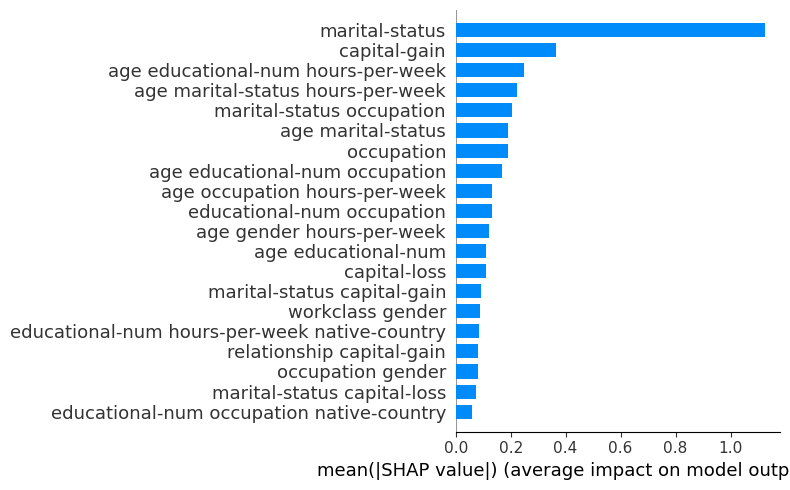

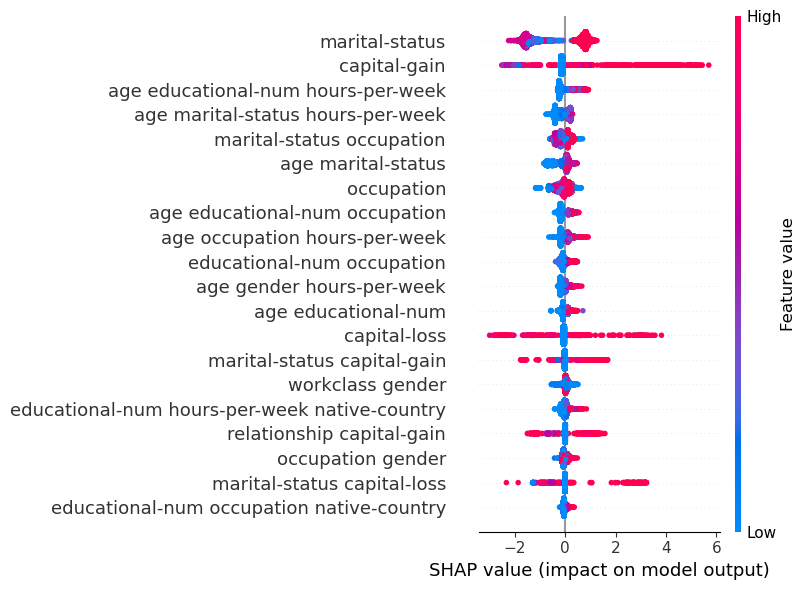

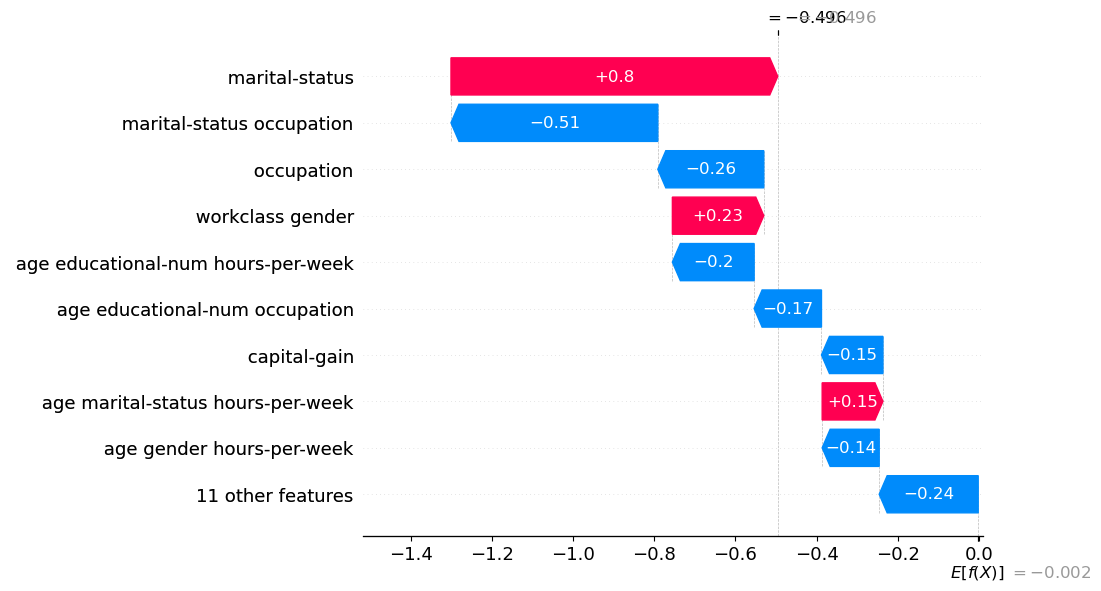

In [23]:
# --- SHAP on reduced XGBoost model (top 20 features) ---

import shap

# Create explainer
explainer_xgb_20 = shap.TreeExplainer(xgb_baseline_xgb_20)

# Compute SHAP values on test set
shap_values_xgb_20 = explainer_xgb_20.shap_values(X_test_xgb_20)

# 1. Global feature importance (bar plot)
shap.summary_plot(
    shap_values_xgb_20,
    X_test_xgb_20,
    plot_type="bar",
    plot_size=(8, 5)
)

# 2. Global direction + spread (beeswarm plot)
shap.summary_plot(
    shap_values_xgb_20,
    X_test_xgb_20,
    plot_size=(8, 6)
)

# 3. Single observation explanation
shap.plots._waterfall.waterfall_legacy(
    explainer_xgb_20.expected_value,
    shap_values_xgb_20[0],
    X_test_xgb_20.iloc[0]
)

### MetaLearner using OOF predictions

In [82]:
# comparing balanced accuracy scores across adult_fe data
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))    
print("Stacked Model Test Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
Stacked Model Test Balanced Accuracy: 0.8169878594503708


In [24]:
# OOF stacking on reduced top-20 polynomial feature sets
# base models: RF top-20 features + XGB top-20 features
# meta learner: Logistic Regression

from sklearn.linear_model import LogisticRegression

# base models (same settings as your reduced models)
rf_stack = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

xgb_stack = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42
)

# meta model
meta_model = LogisticRegression(max_iter=1000)

# OOF setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# store OOF predictions
rf_oof = np.zeros(len(X_train_rf_20))
xgb_oof = np.zeros(len(X_train_xgb_20))

# generate OOF predictions
for train_idx, val_idx in skf.split(X_train_rf_20, y_train):
    X_tr_rf, X_val_rf = X_train_rf_20.iloc[train_idx], X_train_rf_20.iloc[val_idx]
    X_tr_xgb, X_val_xgb = X_train_xgb_20.iloc[train_idx], X_train_xgb_20.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]

    rf_stack.fit(X_tr_rf, y_tr)
    xgb_stack.fit(X_tr_xgb, y_tr)

    rf_oof[val_idx] = rf_stack.predict_proba(X_val_rf)[:, 1]
    xgb_oof[val_idx] = xgb_stack.predict_proba(X_val_xgb)[:, 1]

# train meta model on OOF predictions
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model.fit(X_meta_train, y_train)

# retrain base models on full training data
rf_stack.fit(X_train_rf_20, y_train)
xgb_stack.fit(X_train_xgb_20, y_train)

# generate test predictions
rf_test = rf_stack.predict_proba(X_test_rf_20)[:, 1]
xgb_test = xgb_stack.predict_proba(X_test_xgb_20)[:, 1]

# meta model final predictions
X_meta_test = np.column_stack((rf_test, xgb_test))
meta_preds = meta_model.predict(X_meta_test)

# evaluate
print("Stacked Model Balanced Accuracy:",
      balanced_accuracy_score(y_test, meta_preds))

Stacked Model Balanced Accuracy: 0.8104735508508907


# PyCaret

In [26]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 59.1 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 60.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [101 lines of output]
      + meson setup /private/var/folders/43/c3w99cqd52j7jj26t31tvs_r0000gn/T/pip-install-ccmq5_zy/pandas_17934294bc6c4143a2d0b357a37f3438 /private/var/folders/43/c3w99cqd52j7jj26t31tvs_r0000gn/T/pip-install-ccmq5_zy/pandas_17934294bc6c4143a2d0b357a37f3438/.mesonpy-wll7o9xr/build -Dbuildtype=release -Db_ndebug=if-release -

In [29]:
import sys
!{sys.executable} -m pip install pycaret

  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached numpy-1.26.4-cp313-cp313-macosx_26_0_arm64.whl
  Using cached pandas-2.1.4.tar.gz (4.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [101 lines of output]
      + meson setup /private/var/folders/43/c3w99cqd52j7jj26t31tvs_r0000gn/T/pip-install-ihcqo_ek/pandas_1e3df30fc5fc420a8f085980ace6beef /private/var/folders/43/c3w99cqd52j7jj26t31tvs_r0000gn/T/pip-install-ihcqo_ek/pandas_1e3df30fc5fc420a8f085980ace6beef/.mesonpy-8gi6mh3y/build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=/private/var/folders/43/c3w99cqd52j7jj26t31tvs_r0000gn/T/pip-install-ihcqo_ek/pandas_1e3df30fc5fc420a8f085980ace6beef/.mesonpy-8gi6mh3y/build/m

In [28]:
# PyCaret full workflow on adult_fe data
# Standalone code cell for reuse as desired

from pycaret.classification import *

# combine training features and target for PyCaret
train_fe = X_train_fe.copy()
train_fe["income"] = y_train.values

test_fe = X_test_fe.copy()
test_fe["income"] = y_test.values

# setup experiment
clf_setup = setup(
    data=train_fe,
    target="income",
    session_id=42,
    fold_strategy="stratifiedkfold",
    fold=5,
    numeric_imputation="median",
    categorical_imputation="mode",
    normalize=False,
    silent=True,
    verbose=False
)

# compare models
best_model = compare_models()

# tune best model
tuned_model = tune_model(best_model)

# optional: blend top models
blended_model = blend_models()

# optional: stack top models
stacked_model = stack_models()

# finalize chosen model (pick one: tuned_model, blended_model, or stacked_model)
final_model = finalize_model(stacked_model)

# predict on held-out test set
preds = predict_model(final_model, data=test_fe)

# show results
preds.head()
print(preds.head())

print("\nPyCaret Model Performance:")
print(preds["Label"].value_counts())

ModuleNotFoundError: No module named 'pycaret'

# GRAVEYARD

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# importing the data
adult = pd.read_csv("adult.csv")

# 1. Clean Data Values (Crucial for the Adult dataset)
# This removes leading/trailing spaces from the entries themselves
adult = adult.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Encoding the Target Variable
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# 3. Separate Features and Target
X = adult.drop('income', axis=1)
y = adult['income']

numeric_features = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

# 4. Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Build the Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. Stratified Split (Training/Test)
# stratify=y ensures the 25/75 split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Stratified Cross-Validation
# shuffle=True and stratify ensures no fold is missing a class
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'feature_selection__estimator__C': [0.1, 1.0],
    'classifier__n_estimators': [100]
}



# 8. Run Workflow
grid_search = GridSearchCV(full_pipeline, param_grid, cv=skf, scoring='balanced_accuracy')
grid_search.fit(X_train, y_train)

# --- RESULTS ---
print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Identifying the "Kept" Features
selector = grid_search.best_estimator_.named_steps['feature_selection']
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
final_features = feature_names[selector.get_support()]

print(f"Features selected by Lasso: {len(final_features)} out of {len(feature_names)}")



Best CV Accuracy: 0.7734
Features selected by Lasso: 43 out of 108


In [31]:
# --- RESULTS SUMMARY ---

best_pipe = grid_search.best_estimator_

print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Extract components
selector = best_pipe.named_steps["feature_selection"]
preprocessor = best_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
final_features = feature_names[mask]

# --- 1. Encoded Features ---
print(f"\nEncoded features selected by Lasso: {len(final_features)} out of {len(feature_names)}")

print("\nSelected encoded features (first 50 shown):")
for f in final_features[:50]:
    print(f)

# --- 2. Map Back to Original Features ---
selected_original_features = set()

for f in final_features:
    if f.startswith("num__"):
        selected_original_features.add(f.replace("num__", ""))
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        matched = False
        for col in categorical_features:
            prefix = col + "_"
            if remainder.startswith(prefix):
                selected_original_features.add(col)
                matched = True
                break
        if not matched:
            selected_original_features.add(remainder)

all_original_features = set(numeric_features + categorical_features)

# --- 3. Clean Output for Engineering ---
print("\n\n=== ORIGINAL FEATURES KEPT ===")
for f in sorted(selected_original_features):
    print(f)

print(f"\nKept {len(selected_original_features)} out of {len(all_original_features)} original features")

# --- 4. What Was Removed ---
removed_original_features = all_original_features - selected_original_features

print("\n=== ORIGINAL FEATURES REMOVED ===")
for f in sorted(removed_original_features):
    print(f)

# --- 5. Grouped Summary (VERY useful) ---
from collections import defaultdict

grouped = defaultdict(int)

for f in final_features:
    if f.startswith("num__"):
        grouped[f.replace("num__", "")] += 1
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        for col in categorical_features:
            if remainder.startswith(col + "_"):
                grouped[col] += 1
                break

print("\n=== FEATURE USAGE SUMMARY ===")
for k in sorted(grouped):
    print(f"{k}: {grouped[k]} encoded features selected")


Best CV Accuracy: 0.7734

Encoded features selected by Lasso: 43 out of 108

Selected encoded features (first 50 shown):
num__age
num__fnlwgt
num__educational-num
num__capital-gain
num__capital-loss
num__hours-per-week
cat__workclass_Federal-gov
cat__workclass_Local-gov
cat__workclass_Private
cat__workclass_Self-emp-inc
cat__workclass_Self-emp-not-inc
cat__workclass_State-gov
cat__education_11th
cat__education_Assoc-acdm
cat__education_Assoc-voc
cat__education_HS-grad
cat__education_Prof-school
cat__education_Some-college
cat__marital-status_Divorced
cat__marital-status_Married-civ-spouse
cat__marital-status_Never-married
cat__occupation_?
cat__occupation_Exec-managerial
cat__occupation_Farming-fishing
cat__occupation_Handlers-cleaners
cat__occupation_Machine-op-inspct
cat__occupation_Other-service
cat__occupation_Prof-specialty
cat__occupation_Protective-serv
cat__occupation_Sales
cat__occupation_Tech-support
cat__occupation_Transport-moving
cat__relationship_Other-relative
cat__rela

# Reflection
evaluate your results by describing how performance changed as you reduced features, which features were consistently important, which features you removed and why, whether stacking improved performance, and what you learned about how your model behaves.




Reducing features had different effects on performance. For example, the original fe dataset performed well, but expanding to 377 polynomial features did not improve results significantly. Simplifying to the top 20 features made the models more simple, but slightly decreased accuracy, especially for RF. 

The most important features were capital gain, marital status, education, occupation, and hours worked. Interaction terms involving capital gain were also important in the polynomial set. Many features were removed because they added little value to the model or were just noise.

Stacking did not improve performance overall this time. The stacked model performed worse than the best individual model (XG). This showed that combining models is not always helpful when one model is much stronger than the other.

I learned that increasing feature complexity does not guarantee better performance. Certain feature selection and modeling choices are more important than simply adding more features.